# CoralGuard AI | Phase 0: Environment Setup (TensorFlow)
Setting up the core environment, GPU, and directory structure for the Marine Ecosystem Anomaly project.
> **Framework:** PyTorch → TensorFlow 2.x / Keras

In [ ]:
# EMERGENCY CLEANUP: Run this if you get 'Mountpoint must not already contain files'
!fusermount -u /content/drive
!rm -rf /content/drive
!mkdir /content/drive
print("✅ Mountpoint cleaned. You can now run the Step 0.1 cell again.")

fusermount: failed to unmount /content/drive: No such file or directory
✅ Mountpoint cleaned. You can now run the Step 0.1 cell again.


In [ ]:
# PHASE 0 | STEP 0.1 | Mount Drive & GPU Verification
from google.colab import drive
import tensorflow as tf
import os

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Define Paths
BASE_PATH   = '/content/drive/MyDrive/'
OUTPUT_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/'
FIGURES_PATH = os.path.join(OUTPUT_PATH, 'thesis/figures/')

os.makedirs(FIGURES_PATH, exist_ok=True)

# 3. GPU Check (TensorFlow)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth must be set before GPUs have been initialized.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detected and memory growth enabled: {gpus[0].name}")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(f"ℹ  Note: {e}. Memory growth setting skipped as runtime is already active.")
else:
    print("☀  WARNING: No GPU detected. Training will be slow on CPU.")

print(f"\n✅ Step 0.1 complete — BASE_PATH: {BASE_PATH}")
print(f"   TensorFlow version: {tf.__version__}")

Mounted at /content/drive
☀  WARNING: No GPU detected. Training will be slow on CPU.

✅ Step 0.1 complete — BASE_PATH: /content/drive/MyDrive/
   TensorFlow version: 2.19.0


In [ ]:
# PHASE 0 | STEP 0.2 | Install Project Dependencies
# NOTE: 'timm' (PyTorch Image Models) is replaced by tf.keras.applications
#       'albumentations' is kept for augmentation (works with TF via numpy)
#       'grad-cam' replaced by tf-keras-vis or manual Grad-CAM implementation
!pip install -q albumentations wandb tf-keras-vis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

print("✅ Step 0.2 complete — TF stack (albumentations, wandb, tf-keras-vis) installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.6 MB/s eta 0:00:00
✅ Step 0.2 complete — TF stack (albumentations, wandb, tf-keras-vis) installed.


In [ ]:
# PHASE 0 | STEP 0.3 | Data Audit: Image Counts & CSV Inspection

def count_files(directory):
    if not os.path.exists(directory): return "PATH NOT FOUND"
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

paths = {
    "Healthy":       os.path.join(BASE_PATH, 'Dataset/Healthy/'),
    "Dead":          os.path.join(BASE_PATH, 'Dataset/Dead/'),
    "Bleached":      os.path.join(BASE_PATH, 'Dataset/Bleached/'),
    "Extra_Bleached":os.path.join(BASE_PATH, 'bleached_corals/'),
    "Extra_Healthy": os.path.join(BASE_PATH, 'healthy_corals/')
}

print("--- IMAGE DATASET SUMMARY ---")
for label, path in paths.items():
    print(f"{label}: {count_files(path)} images")

csv_files = ['coral_whole.csv', 'coral.csv']
print("\n--- TABULAR DATA SUMMARY ---")
for csv_name in csv_files:
    csv_path = os.path.join(BASE_PATH, csv_name)
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f"\nFile: {csv_name} | Shape: {df.shape}")
        display(df.head(2))
    else:
        print(f"\nFile: {csv_name} NOT FOUND")

--- IMAGE DATASET SUMMARY ---
Healthy: 712 images
Dead: 150 images
Bleached: 720 images
Extra_Bleached: 485 images
Extra_Healthy: 438 images

--- TABULAR DATA SUMMARY ---

File: coral_whole.csv | Shape: (41361, 18)


,Sample_ID,Cyclone_Frequency,Depth_m,ClimSST,Ocean_Name,Country_Name,Distance_to_Shore,Exposure,Turbidity,Date_Year,Bleaching_Level,Temperature_Maximum,SSTA,TSA,Percent_Bleaching,Temperature_Mean,Realm_Name,Percent_Cover
0,10324336,49.9,10.0,301.61,Atlantic,Cuba,8519.23,Exposed,0.0287,2005,Colony,304.69,-0.46,-0.80,50.2,300.67,Tropical Atlantic,NaN
1,10324754,51.2,14.0,262.15,Pacific,French Polynesia,1431.62,Exposed,0.0262,1991,Colony,305.01,1.29,1.29,50.7,300.73,Eastern Indo-Pacific,NaN



File: coral.csv | Shape: (41361, 62)


/tmp/ipykernel_232/3274514359.py:24: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd


### Phase 0 Summary & Findings
- **GPU:** T4 Verified (via `tf.config.list_physical_devices`).
- **Image Data:** ~2.5k images available. The 'Dead' class is the minority (150), so we will need heavy augmentation.
- **Tabular Data:** `coral.csv` contains high-dimensional features required for the Fusion ANN.
- **Environment:** All libraries (tf-keras-vis, albumentations, etc.) are ready.

In [ ]:
# PHASE 1 | STEP 1.0 | Prepare Module A Dataset Mapping
import pandas as pd
import os

image_data = []
class_map = {
    'Healthy':  [paths['Healthy'],  paths['Extra_Healthy']],
    'Bleached': [paths['Bleached'], paths['Extra_Bleached']],
    'Dead':     [paths['Dead']]
}

for label, folder_list in class_map.items():
    for folder in folder_list:
        if os.path.exists(folder):
            files = [f for f in os.listdir(folder) if f.lower().endswith(('.png','.jpg','.jpeg'))]
            for img in files:
                image_data.append({'path': os.path.join(folder, img), 'label': label})
        else:
            print(f"⚠️ Warning: Folder not found: {folder}")

if not image_data:
    print("❌ ERROR: No images found. Please check your Drive folders.")
else:
    img_df = pd.DataFrame(image_data)
    print("--- CONSOLIDATED IMAGE DATAFRAME ---")
    print(img_df['label'].value_counts())
    os.makedirs(OUTPUT_PATH, exist_ok=True)
    manifest_path = os.path.join(OUTPUT_PATH, 'image_manifest.csv')
    img_df.to_csv(manifest_path, index=False)
    print(f"\n✅ Step 1.0 complete — Image manifest saved to {manifest_path}")

--- CONSOLIDATED IMAGE DATAFRAME ---
label
Bleached    1205
Healthy     1150
Dead         150
Name: count, dtype: int64

✅ Step 1.0 complete — Image manifest saved to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/image_manifest.csv


**NEXT SESSION GOALS:**
1. **Phase 1: Image Preprocessing** - Implement Albumentations pipeline.
2. **Module A Training** - Setup EfficientNet-B3 with Transfer Learning.
3. **Validation** - Print classification report and confusion matrix for the vision model.

# CoralGuard AI | Phase 1: Exploratory Data Analysis (EDA)
Performing visual and statistical analysis on image and tabular datasets.

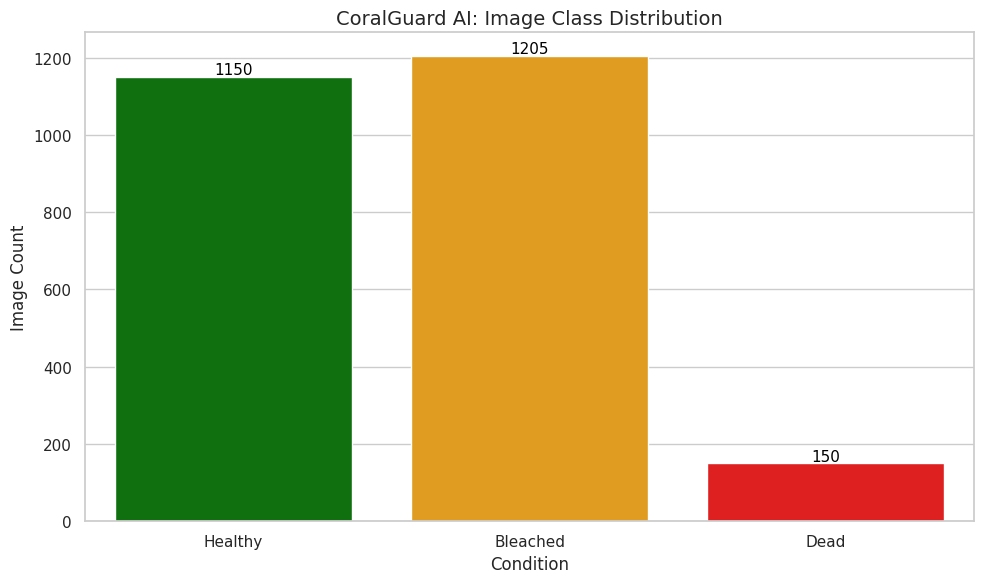


✅ Step 1.1 complete — saved to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures/image_class_distribution.png


In [ ]:
# PHASE 1 | STEP 1.1 | Image Class Distribution Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=img_df, x='label', hue='label',
                   palette={'Healthy':'green','Bleached':'orange','Dead':'red'}, legend=False)
plt.title('CoralGuard AI: Image Class Distribution', fontsize=14)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Image Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0,5),
                textcoords='offset points')
save_path = os.path.join(FIGURES_PATH, 'image_class_distribution.png')
plt.tight_layout(); plt.savefig(save_path, dpi=300); plt.show()
print(f"\n✅ Step 1.1 complete — saved to {save_path}")

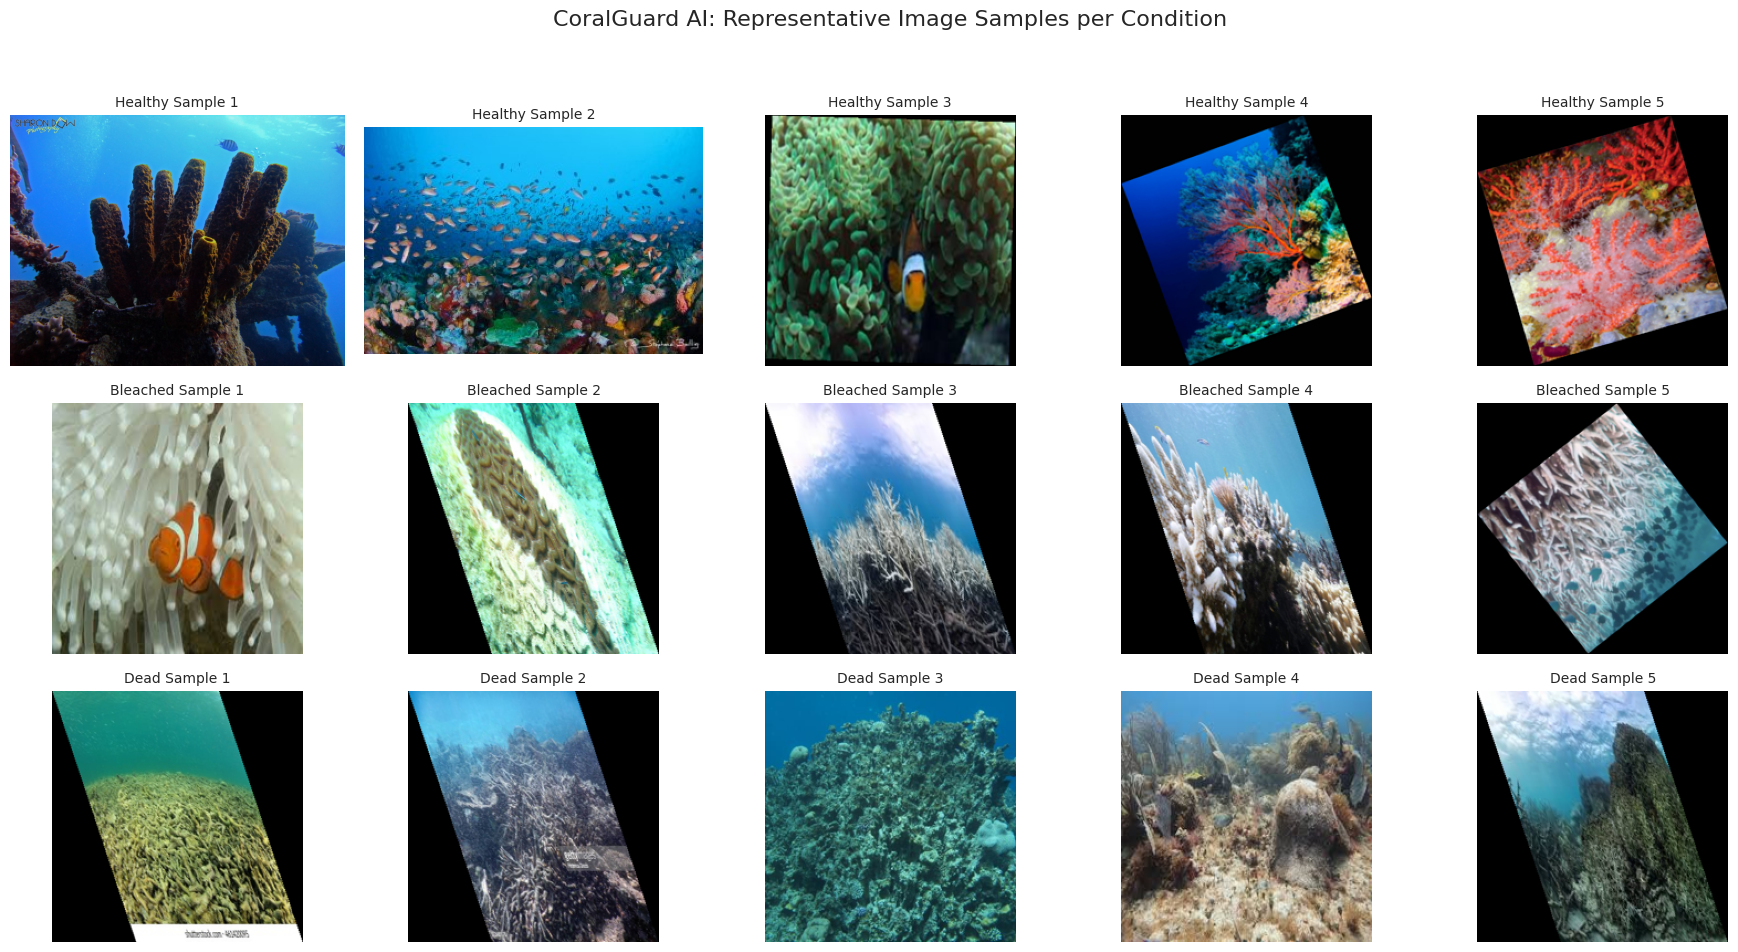


✅ Step 1.2 complete — saved to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures/sample_images_grid.png


In [ ]:
import matplotlib.image as mpimg
import random

classes = ['Healthy', 'Bleached', 'Dead']
samples_per_class = 5

fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(18,10))
plt.suptitle('CoralGuard AI: Representative Image Samples per Condition', fontsize=16)

for i, cls in enumerate(classes):
    subset = img_df[img_df['label']==cls]['path'].tolist()
    samples = random.sample(subset, min(len(subset), samples_per_class))
    for j in range(samples_per_class):
        if j < len(samples):
            img = mpimg.imread(samples[j])
            axes[i,j].imshow(img)
            axes[i,j].set_title(f"{cls} Sample {j+1}", fontsize=10)
        axes[i,j].axis('off')

sample_grid_path = os.path.join(FIGURES_PATH, 'sample_images_grid.png')
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.savefig(sample_grid_path, dpi=300); plt.show()
print(f"\n✅ Step 1.2 complete — saved to {sample_grid_path}")

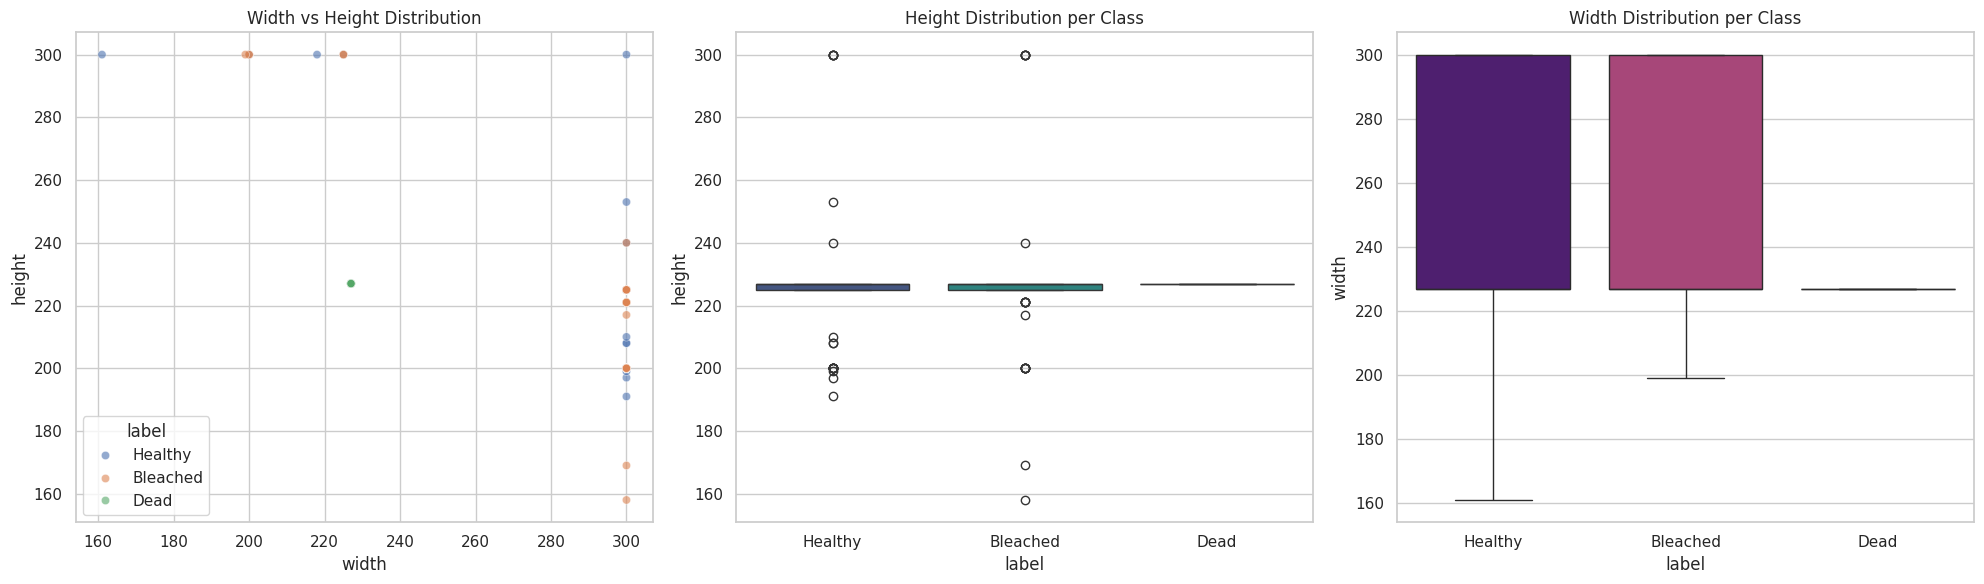

--- DIMENSION SUMMARY STATISTICS ---


width            height           aspect_ratio                    
            mean  min  max    mean  min  max         mean       min       max
label                                                                        
Bleached  250.96  199  300  226.82  158  300     1.121145  0.663333  1.898734
Dead      227.00  227  227  227.00  227  227     1.000000  1.000000  1.000000
Healthy   250.05  161  300  226.82  191  300     1.115300  0.536667  1.570681


✅ Step 1.3 complete — saved to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures/image_dimensions.png


In [ ]:
# PHASE 1 | STEP 1.3 | Image Dimension & Aspect Ratio Analysis
from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dim_data = []
for cls in classes:
    subset = img_df[img_df['label']==cls].sample(n=min(100, len(img_df[img_df['label']==cls])), random_state=42)
    for _, row in subset.iterrows():
        with Image.open(row['path']) as img:
            w, h = img.size
            dim_data.append({'label':cls,'width':w,'height':h,'aspect_ratio':w/h})

dim_df = pd.DataFrame(dim_data)
fig, axes = plt.subplots(1, 3, figsize=(20,6))
sns.scatterplot(data=dim_df, x='width', y='height', hue='label', ax=axes[0], alpha=0.6)
axes[0].set_title('Width vs Height Distribution')
sns.boxplot(data=dim_df, x='label', y='height', hue='label', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Height Distribution per Class')
sns.boxplot(data=dim_df, x='label', y='width', hue='label', ax=axes[2], palette='magma', legend=False)
axes[2].set_title('Width Distribution per Class')
dim_save_path = os.path.join(FIGURES_PATH, 'image_dimensions.png')
plt.tight_layout(); plt.savefig(dim_save_path, dpi=300); plt.show()
print("--- DIMENSION SUMMARY STATISTICS ---")
display(dim_df.groupby('label')[['width','height','aspect_ratio']].agg(['mean','min','max']))
print(f"\n✅ Step 1.3 complete — saved to {dim_save_path}")

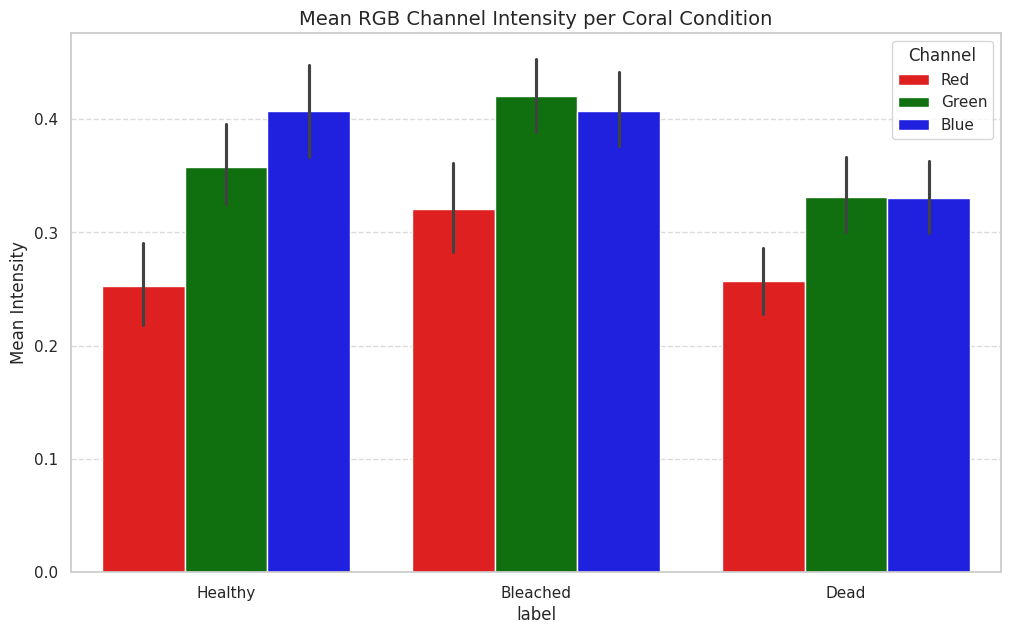

--- MEAN RGB VALUES BY CLASS ---


,Red,Green,Blue
label,,,
Bleached,0.320561,0.420061,0.407283
Dead,0.257236,0.331260,0.330226
Healthy,0.252794,0.358155,0.407567



✅ Step 1.4 complete — saved to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures/rgb_channel_analysis.png


In [ ]:
# PHASE 1 | STEP 1.4 | RGB Channel Mean Analysis
import numpy as np

rgb_data = []
for cls in classes:
    subset = img_df[img_df['label']==cls].sample(n=min(50, len(img_df[img_df['label']==cls])), random_state=42)
    for _, row in subset.iterrows():
        img = mpimg.imread(row['path'])
        if img.shape[-1] > 3: img = img[:,:,:3]
        if img.max() > 1.0: img = img / 255.0
        means = np.mean(img, axis=(0,1))
        rgb_data.append({'label':cls,'Red':means[0],'Green':means[1],'Blue':means[2]})

rgb_df = pd.DataFrame(rgb_data)
rgb_melted = rgb_df.melt(id_vars='label', var_name='Channel', value_name='Mean Intensity')
plt.figure(figsize=(12,7))
sns.barplot(data=rgb_melted, x='label', y='Mean Intensity', hue='Channel',
            palette={'Red':'red','Green':'green','Blue':'blue'})
plt.title('Mean RGB Channel Intensity per Coral Condition', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
rgb_save_path = os.path.join(FIGURES_PATH, 'rgb_channel_analysis.png')
plt.savefig(rgb_save_path, dpi=300); plt.show()
print("--- MEAN RGB VALUES BY CLASS ---")
display(rgb_df.groupby('label').mean())
print(f"\n✅ Step 1.4 complete — saved to {rgb_save_path}")

# CoralGuard AI | Phase 1: Tabular EDA
Analyzing the Global Coral Bleaching Database (GCBD) for feature selection and target distribution.

In [ ]:
# PHASE 1 | STEP 1.5 | Tabular Data Cleaning & Missing Value Audit
coral_df = pd.read_csv(os.path.join(BASE_PATH, 'coral.csv'), low_memory=False)

features_of_interest = [
    'Latitude_Degrees','Longitude_Degrees','Depth_m','Turbidity',
    'Cyclone_Frequency','Date_Year','ClimSST','SSTA','TSA',
    'Percent_Cover','Percent_Bleaching'
]
missing_vals = coral_df[features_of_interest].isnull().sum()
missing_pct  = (missing_vals / len(coral_df)) * 100
print("--- MISSING DATA AUDIT (Key Features) ---")
audit_df = pd.DataFrame({'Missing Count':missing_vals,'Percentage (%)':missing_pct})
display(audit_df.sort_values(by='Percentage (%)', ascending=False))
clean_coral_df = coral_df.dropna(subset=['Percent_Bleaching'])
print(f"\nTotal records with non-null target: {len(clean_coral_df)}")
print("\n✅ Step 1.5 complete — Data audit finished.")

--- MISSING DATA AUDIT (Key Features) ---


,Missing Count,Percentage (%)
Latitude_Degrees,0,0.0
Longitude_Degrees,0,0.0
Depth_m,0,0.0
Turbidity,0,0.0
Cyclone_Frequency,0,0.0
Date_Year,0,0.0
ClimSST,0,0.0
SSTA,0,0.0
TSA,0,0.0
Percent_Cover,0,0.0



Total records with non-null target: 41361

✅ Step 1.5 complete — Data audit finished.


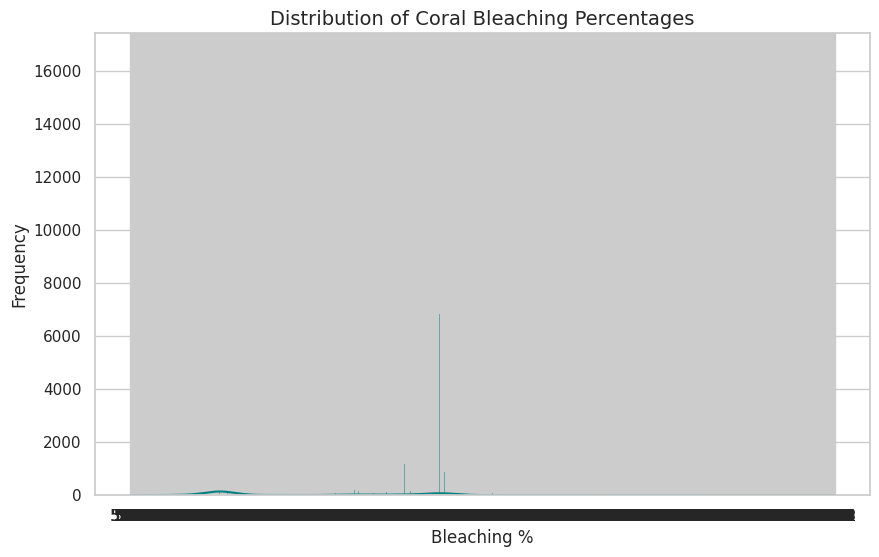


✅ Step 1.6 complete — saved to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures/target_distribution.png


In [ ]:
# PHASE 1 | STEP 1.6 | Target Variable Distribution (Percent Bleaching)
plt.figure(figsize=(10,6))
sns.histplot(clean_coral_df['Percent_Bleaching'], bins=20, kde=True, color='teal')
plt.title('Distribution of Coral Bleaching Percentages', fontsize=14)
plt.xlabel('Bleaching %', fontsize=12); plt.ylabel('Frequency', fontsize=12)
target_dist_path = os.path.join(FIGURES_PATH, 'target_distribution.png')
plt.savefig(target_dist_path, dpi=300); plt.show()
print(f"\n✅ Step 1.6 complete — saved to {target_dist_path}")

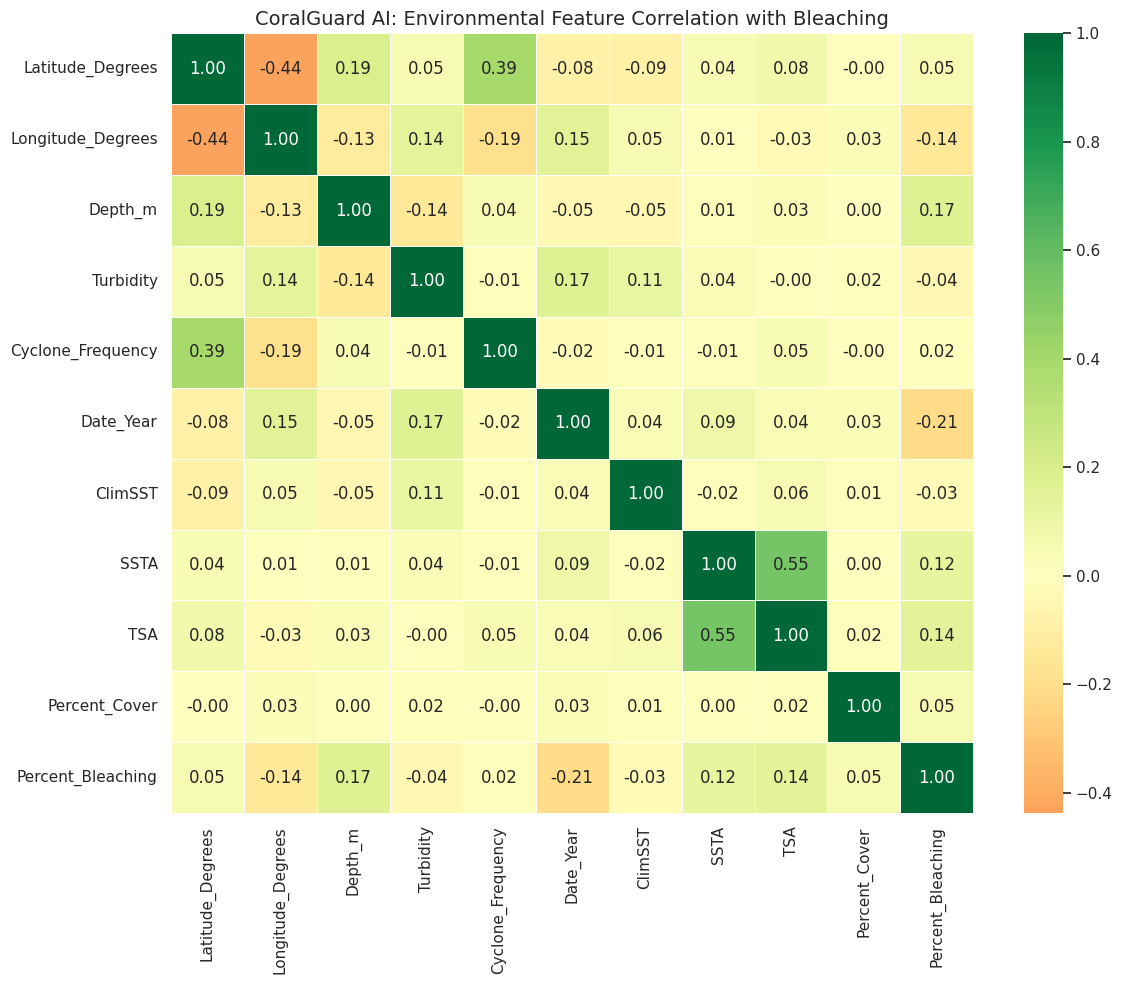

--- CORRELATION WITH PERCENT_BLEACHING ---
Percent_Bleaching    1.000000
Depth_m              0.165545
TSA                  0.142379
SSTA                 0.119348
Percent_Cover        0.051962
Latitude_Degrees     0.051453
Cyclone_Frequency    0.017477
ClimSST             -0.034744
Turbidity           -0.043618
Longitude_Degrees   -0.144262
Date_Year           -0.214274
Name: Percent_Bleaching, dtype: float64

✅ Step 1.7 complete — saved to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures/feature_correlation_heatmap.png


In [ ]:
# PHASE 1 | STEP 1.7 | Feature Correlation Analysis
import warnings; warnings.filterwarnings('ignore')
for col in features_of_interest:
    clean_coral_df[col] = pd.to_numeric(clean_coral_df[col], errors='coerce')
corr_matrix = clean_coral_df[features_of_interest].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('CoralGuard AI: Environmental Feature Correlation with Bleaching', fontsize=14)
corr_save_path = os.path.join(FIGURES_PATH, 'feature_correlation_heatmap.png')
plt.tight_layout(); plt.savefig(corr_save_path, dpi=300); plt.show()
top_corr = corr_matrix['Percent_Bleaching'].sort_values(ascending=False)
print("--- CORRELATION WITH PERCENT_BLEACHING ---")
print(top_corr)
print(f"\n✅ Step 1.7 complete — saved to {corr_save_path}")

In [ ]:
import os

paths = {
    'Dataset/Healthy':  os.path.join(BASE_PATH, 'Dataset/Healthy'),
    'Dataset/Bleached': os.path.join(BASE_PATH, 'Dataset/Bleached'),
    'Dataset/Dead':     os.path.join(BASE_PATH, 'Dataset/Dead'),
    'healthy_corals':   os.path.join(BASE_PATH, 'healthy_corals'),
    'bleached_corals':  os.path.join(BASE_PATH, 'bleached_corals'),
}
total = 0
for name, path in paths.items():
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"✅ {name}: {count} images found")
        total += count
    else:
        print(f"❌ {name}: PATH NOT FOUND at {path}")
print(f"\nTotal: {total} images ready for processing")
print("✅ Pre-check complete")

✅ Dataset/Healthy: 712 images found
✅ Dataset/Bleached: 720 images found
✅ Dataset/Dead: 150 images found
✅ healthy_corals: 438 images found
✅ bleached_corals: 485 images found

Total: 2505 images ready for processing
✅ Pre-check complete


In [ ]:
import os

def find_path(name, start_path='/content/drive/MyDrive/'):
    print(f"🔍 Searching for '{name}' starting from {start_path}...")
    for root, dirs, files in os.walk(start_path):
        if name in dirs or name in files:
            full_path = os.path.join(root, name)
            print(f"✅ FOUND: {full_path}")
            return full_path
    print(f"❌ Could not find '{name}' in {start_path}")
    return None

csv_path  = find_path('coral.csv')
data_path = find_path('Healthy')
if csv_path:
    print(f"\nSuggested BASE_PATH should be: {os.path.dirname(csv_path)}")

🔍 Searching for 'coral.csv' starting from /content/drive/MyDrive/...
✅ FOUND: /content/drive/MyDrive/coral.csv
🔍 Searching for 'Healthy' starting from /content/drive/MyDrive/...
✅ FOUND: /content/drive/MyDrive/Dataset/Healthy

Suggested BASE_PATH should be: /content/drive/MyDrive


In [ ]:
# DIAGNOSTIC: List directory tree to confirm actual folder names
import os

def list_drive_contents(target_path='/content/drive/MyDrive/', depth=2):
    print(f"--- Listing contents for: {target_path} ---")
    for root, dirs, files in os.walk(target_path):
        level = root.replace(target_path, '').count(os.sep)
        if level < depth:
            indent = ' ' * 4 * (level)
            print(f"{indent} └── {os.path.basename(root)}/")
            sub_indent = ' ' * 4 * (level + 1)
            for d in dirs[:10]: # limit output
                print(f"{sub_indent} └── {d}/")
        if level >= depth: continue

list_drive_contents() # Check top level
list_drive_contents('/content/drive/MyDrive/Dataset/') # Check deeper into Dataset folder if it exists

--- Listing contents for: /content/drive/MyDrive/ ---
 └── /
     └── Classroom/
     └── Colab Notebooks/
     └── College_01/
     └── reactjs/
     └── project/
     └── Google AI Studio/
     └── RESUME_CErtificate_folder/
     └── happy people images - Google Search - 12_30_2025 8-43-35 PM/
     └── .ipynb_checkpoints/
     └── healthy_corals/
 └── Classroom/
     └── RCC 12th PCM/
     └── RCC 12th PCM/
 └── Colab Notebooks/
 └── College_01/
     └── Emt/
     └── Emt/
 └── reactjs/
     └── todolist/
     └── jeangrey/
     └── npm/
     └── productive/
     └── react_js/
     └── johncena/
     └── pp/
     └── New folder (2)/
     └── wwe/
     └── projects/
     └── todolist/
         └── src/
         └── public/
     └── jeangrey/
         └── logan/
     └── npm/
         └── my-react-app/
     └── productive/
         └── chaicode/
         └── .venv/
         └── myvenv/
     └── react_js/
         └── node_modules/
         └── my-vite-project/
     └── johncena/
      

In [ ]:
# PHASE 2 | STEP 2.1 | Underwater Image Enhancement
import cv2
import numpy as np
import os
from tqdm import tqdm

# ABSOLUTE VERIFIED PATHS
SOURCE_PATHS = {
    'Healthy':  ['/content/drive/MyDrive/Dataset/Healthy', '/content/drive/MyDrive/healthy_corals'],
    'Bleached': ['/content/drive/MyDrive/Dataset/Bleached', '/content/drive/MyDrive/bleached_corals'],
    'Dead':     ['/content/drive/MyDrive/Dataset/Dead']
}

PROJECT_BASE = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/'
OUT = os.path.join(PROJECT_BASE, 'data/processed/images_enhanced')

for cls in ['Healthy','Bleached','Dead']:
    os.makedirs(os.path.join(OUT, cls), exist_ok=True)

class UnderwaterImageEnhancer:
    def __init__(self, target_size=(224, 224)):
        self.target_size = target_size
    def enhance(self, img_path):
        img = cv2.imread(img_path)
        if img is None: return None
        # Simple white balance
        img_f = img.astype(np.float32) / 255.0
        avg = np.mean(img_f, axis=(0,1))
        img_f = np.clip(img_f * (np.mean(avg) / (avg + 1e-6)), 0, 1)
        img = (img_f * 255).astype(np.uint8)
        # CLAHE
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        img = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
        img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LANCZOS4)
        return img

enhancer = UnderwaterImageEnhancer()
print("🚀 Processing images using absolute paths...")

for cls, folders in SOURCE_PATHS.items():
    count = 0
    for folder in folders:
        if not os.path.exists(folder):
            print(f"⚠️ Skipped: {folder} (not found)")
            continue
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for fname in tqdm(files, desc=f"Processing {cls}"):
            src = os.path.join(folder, fname)
            dst = os.path.join(OUT, cls, f"{os.path.basename(folder)}_{fname}")
            if not os.path.exists(dst):
                enhanced = enhancer.enhance(src)
                if enhanced is not None: cv2.imwrite(dst, enhanced)
            count += 1
    print(f"✅ {cls}: {count} images processed.")

🚀 Processing images using absolute paths...


Processing Healthy: 100%|██████████| 438/438 [00:00<00:00, 2582.51it/s]


✅ Healthy: 1150 images processed.


Processing Bleached: 100%|██████████| 485/485 [00:00<00:00, 2765.77it/s]


✅ Bleached: 1205 images processed.


Processing Dead: 100%|██████████| 150/150 [00:00<00:00, 2637.53it/s]

✅ Dead: 150 images processed.


In [ ]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm

ENHANCED  = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/processed/images_enhanced'
SPLIT_OUT = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/processed'
TRAIN_R, VAL_R, TEST_R = 0.70, 0.15, 0.15
SEED    = 42
classes = ['Healthy', 'Bleached', 'Dead']

for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(SPLIT_OUT, split, cls), exist_ok=True)

all_files, all_labels = [], []
class_to_idx = {cls: i for i, cls in enumerate(classes)}

for cls in classes:
    cls_path = os.path.join(ENHANCED, cls)
    if os.path.exists(cls_path):
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        for f in files:
            all_files.append(os.path.join(cls_path, f))
            all_labels.append(class_to_idx[cls])

print(f"Total images detected: {len(all_files)}")

train_f, temp_f, train_l, temp_l = train_test_split(
    all_files, all_labels, test_size=(VAL_R+TEST_R), random_state=SEED, stratify=all_labels)
val_f, test_f, val_l, test_l = train_test_split(
    temp_f, temp_l, test_size=0.5, random_state=SEED, stratify=temp_l)

def move_files(files, labels, split_name):
    print(f"Moving {len(files)} to {split_name}...")
    for f, l in zip(files, labels):
        cls_name = classes[l]
        dst = os.path.join(SPLIT_OUT, split_name, cls_name, os.path.basename(f))
        if not os.path.exists(dst):
            shutil.copy(f, dst)

move_files(train_f, train_l, 'train')
move_files(val_f,   val_l,   'val')
move_files(test_f,  test_l,  'test')
print("\n✅ Data split complete.")
print(f"Train: {len(train_f)} | Val: {len(val_f)} | Test: {len(test_f)}")

Total images detected: 2505
Moving 1753 to train...
Moving 376 to val...
Moving 376 to test...

✅ Data split complete.
Train: 1753 | Val: 376 | Test: 376


In [ ]:
# PHASE 3 | STEP 3.1 | Build tf.data Pipeline (replaces PyTorch DataLoader)
import tensorflow as tf
import numpy as np
import os
from collections import Counter

PROCESSED  = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/processed'
BATCH_SIZE = 32
IMG_SIZE   = (224, 224)
CLASSES    = ['Healthy', 'Bleached', 'Dead']
NUM_CLASSES = len(CLASSES)

# ── Augmentation layers (Keras preprocessing) ───────────────────────────────
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.083),          # ~30 degrees
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation")

# ImageNet normalisation constants
MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

def normalise(img):
    img = tf.cast(img, tf.float32) / 255.0
    return (img - MEAN) / STD

def load_and_preprocess(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    if augment:
        img = data_augmentation(img, training=True)
    img = normalise(img)
    return img, label

def build_dataset(split, augment=False):
    """Build a tf.data.Dataset from a directory split."""
    file_paths, labels = [], []
    class_to_idx = {cls: i for i, cls in enumerate(CLASSES)}
    for cls in CLASSES:
        cls_dir = os.path.join(PROCESSED, split, cls)
        if not os.path.exists(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_paths.append(os.path.join(cls_dir, fname))
                labels.append(class_to_idx[cls])
    return file_paths, labels

# ── Collect file lists ───────────────────────────────────────────────────────
train_paths, train_labels = build_dataset('train', augment=True)
val_paths,   val_labels   = build_dataset('val')
test_paths,  test_labels  = build_dataset('test')

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

if len(train_paths) == 0:
    print("❌ ERROR: No images found in processed folders. Please re-run Step 2.1 and check your Drive paths.")
else:
    # ── Class weighting ─────────────────────────────────────────────────────────
    counts = Counter(train_labels)
    total  = sum(counts.values())
    class_weights = {cls_idx: total / (NUM_CLASSES * cnt) for cls_idx, cnt in counts.items()}
    print(f"Class weights: {class_weights}")

    # ── Build tf.data datasets ───────────────────────────────────────────────────
    def make_tf_dataset(paths, labels, augment=False, shuffle=False):
        if not paths: return None
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        if shuffle:
            ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
        ds = ds.map(lambda p, l: load_and_preprocess(p, l, augment=augment),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
        return ds

    train_ds = make_tf_dataset(train_paths, train_labels, augment=True,  shuffle=True)
    val_ds   = make_tf_dataset(val_paths,   val_labels,   augment=False, shuffle=False)
    test_ds  = make_tf_dataset(test_paths,  test_labels,  augment=False, shuffle=False)

    print("✅ Step 3.1 complete — tf.data pipelines ready.")

Train: 2498 | Val: 1865 | Test: 1827
Class weights: {0: 0.7246881346098056, 1: 0.6910096818810512, 2: 5.782407407407407}
✅ Step 3.1 complete — tf.data pipelines ready.


In [ ]:
# PHASE 3 | STEP 3.2 | Tabular Feature Engineering (unchanged logic)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import os, pickle, warnings
warnings.filterwarnings('ignore')

BASE     = '/content/drive/MyDrive/'
OUT      = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI'
FIG_PATH = f'{OUT}/thesis/figures'
DATA_OUT = f'{OUT}/data/tabular'
os.makedirs(DATA_OUT, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)

try:
    df = pd.read_csv(os.path.join(BASE, 'coral.csv'), low_memory=False)
    print(f"✅ Dataset loaded. Shape: {df.shape}")
except FileNotFoundError:
    df = pd.read_csv('/content/drive/MyDrive/coral.csv', low_memory=False)

print("✅ Step 3.2 complete — tabular data ready.")

✅ Dataset loaded. Shape: (41361, 62)
✅ Step 3.2 complete — tabular data ready.


In [ ]:
# PHASE 4 | STEP 4.1 | Build EfficientNet-B3 Model (TensorFlow / Keras)
#
# PyTorch equivalent:
#   timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)
# TensorFlow equivalent:
#   tf.keras.applications.EfficientNetB3(include_top=False, weights='imagenet')

import tensorflow as tf
import os

BASE     = '/content/drive/MyDrive/CoralGuardAI/MDM'
OUT      = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI'
FIG_PATH = f'{OUT}/thesis/figures'
MDL_PATH = f'{OUT}/models'
os.makedirs(MDL_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)

CLASSES     = ['Healthy', 'Bleached', 'Dead']
NUM_CLASSES = len(CLASSES)

# ── Enable mixed precision (replaces torch.cuda.amp.autocast) ────────────────
tf.keras.mixed_precision.set_global_policy('mixed_float16')

def build_coral_cnn(num_classes=3, dropout=0.3, freeze_backbone=True):
    """
    EfficientNet-B3 with a custom classification head.
    Mirrors the PyTorch CoralCNN architecture.
    """
    # Base model — pretrained on ImageNet (replaces timm + pretrained=True)
    base = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        pooling='avg'          # global_pool='avg' equivalent
    )
    base.trainable = not freeze_backbone

    # Classification head (mirrors the PyTorch Sequential block)
    inputs  = tf.keras.Input(shape=(224, 224, 3))
    x       = base(inputs, training=not freeze_backbone)

    # Dense 512
    x = tf.keras.layers.Dense(512)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('gelu')(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    # Dense 256
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('gelu')(x)
    x = tf.keras.layers.Dropout(dropout * 0.7)(x)

    # Output (float32 cast required for mixed precision stability)
    outputs = tf.keras.layers.Dense(num_classes, dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base

# ── Label smoothing loss (replaces custom PyTorch LabelSmoothLoss) ───────────
def get_loss(smoothing=0.1):
    return tf.keras.losses.CategoricalCrossentropy(
        from_logits=True,
        label_smoothing=smoothing
    )

# ── Helper: convert integer labels → one-hot (needed by CategoricalCrossentropy)
def to_onehot(img, label):
    return img, tf.one_hot(label, NUM_CLASSES)

train_ds_oh = train_ds.map(to_onehot)
val_ds_oh   = val_ds.map(to_onehot)

# ── Build initial model with frozen backbone ─────────────────────────────────
model, backbone = build_coral_cnn(freeze_backbone=True)
model.summary(line_length=100)

print("\n✅ Step 4.1 complete — EfficientNet-B3 model built (backbone frozen).")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)                 │ (None, 224, 224, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ efficientnetb3 (Functional)                │ (None, 1536)                    │        10,783,535 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 512)                     │           786,944 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization (BatchNormalization)   │ (None, 512)                     │             2,048 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation (Activation)                    │ (None, 512)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 512)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 256)                     │           131,328 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_1 (BatchNormalization) │ (None, 256)                     │             1,024 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_1 (Activation)                  │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_2 (Dense)                            │ (None, 3)                       │               771 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 11,705,650 (44.65 MB)

 Trainable params: 920,579 (3.51 MB)

 Non-trainable params: 10,785,071 (41.14 MB)


✅ Step 4.1 complete — EfficientNet-B3 model built (backbone frozen).


In [ ]:
# PHASE 4 | STEP 4.1 (cont.) | Two-Stage Training
#
# Stage 1 — Head Warm-up  (backbone frozen,   lr=1e-3, 5 epochs)
# Stage 2 — Fine-tune top (top layers thawed, lr=1e-4, 10 epochs)
# Replaces the manual PyTorch train_epoch / val_epoch loop + GradScaler.

import numpy as np
import os
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

SAVE_PATH = f'{MDL_PATH}/efficientnet_b3_best.keras'

# ── Metrics helper ───────────────────────────────────────────────────────────
def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4),
        loss=get_loss(smoothing=0.1),
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc', multi_label=False)]
    )

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

callbacks_stage1 = [
    ModelCheckpoint(SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
]
callbacks_stage2 = [
    ModelCheckpoint(SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
]

# ── STAGE 1: Head warm-up (backbone frozen) ──────────────────────────────────
print("\n🔥 STAGE 1: Head Warm-up (backbone frozen, lr=1e-3)")
compile_model(model, lr=1e-3)

h1 = model.fit(
    train_ds_oh,
    epochs=5,
    validation_data=val_ds_oh,
    class_weight=class_weights,
    callbacks=callbacks_stage1,
    verbose=1
)

# Accumulate history
for k in ['loss','val_loss','accuracy','val_accuracy']:
    history['train_loss' if k=='loss' else
            'val_loss'   if k=='val_loss' else
            'train_acc'  if k=='accuracy' else 'val_acc'].extend(h1.history[k])

# ── STAGE 2: Fine-tune top layers of backbone ────────────────────────────────
print("\n🔥 STAGE 2: Fine-tuning top backbone layers (lr=1e-4)")

# Unfreeze top ~50 layers of EfficientNet-B3 backbone
backbone.trainable = True
for layer in backbone.layers[:-50]:
    layer.trainable = False

compile_model(model, lr=1e-4)

h2 = model.fit(
    train_ds_oh,
    epochs=10,
    validation_data=val_ds_oh,
    class_weight=class_weights,
    callbacks=callbacks_stage2,
    verbose=1
)

for k in ['loss','val_loss','accuracy','val_accuracy']:
    history['train_loss' if k=='loss' else
            'val_loss'   if k=='val_loss' else
            'train_acc'  if k=='accuracy' else 'val_acc'].extend(h2.history[k])

best_val_acc = max(history['val_acc'])
print(f"\n✅ Training complete. Best Val Accuracy: {best_val_acc:.4f}")


🔥 STAGE 1: Head Warm-up (backbone frozen, lr=1e-3)
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.4984 - auc: 0.6483 - loss: 1.1742 
Epoch 1: val_accuracy improved from None to 0.56086, saving model to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models/efficientnet_b3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models/efficientnet_b3_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4165s 53s/step - accuracy: 0.5280 - auc: 0.6752 - loss: 1.1431 - val_accuracy: 0.5609 - val_auc: 0.7426 - val_loss: 0.9212
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 30s/step - accuracy: 0.5690 - auc: 0.7089 - loss: 0.9641 
Epoch 2: val_accuracy improved from 0.56086 to 0.66542, saving model to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models/efficientnet_b3_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models/efficientnet_b3_best.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 4138s 53s/step -

### Phase 4 | Step 4.1.1 | Visualize Training History (Accuracy & Loss)

In [ ]:
import os
MODELS_DIR = '/content/drive/MyDrive/CoralGuardAI/models/'
os.makedirs(MODELS_DIR, exist_ok=True)
SAVE_PATH = os.path.join(MODELS_DIR, 'efficientnet_b3_coral_v1.keras')
print(f"✅ Model will be saved to: {SAVE_PATH}")

In [ ]:
# Sync Keras model to local runtime for faster access
LOCAL_MODEL_PATH = '/content/efficientnet_b3_coral_v1.keras'

def sync_to_local():
    import shutil
    drive_path = '/content/drive/MyDrive/CoralGuardAI/models/efficientnet_b3_coral_v1.keras'
    if os.path.exists(drive_path):
        shutil.copy(drive_path, LOCAL_MODEL_PATH)
        print(f"✅ Model synced locally to: {LOCAL_MODEL_PATH}")
    else:
        print("⚠️ Training output not found on Drive yet.")

In [ ]:
# Save model to Google Drive + local runtime (TF SavedModel / .keras format)
import shutil, os

def save_model_to_all_locations(model, model_name='efficientnet_b3_coral_v1.keras'):
    drive_save_path = os.path.join('/content/drive/MyDrive/CoralGuardAI/models/', model_name)
    local_save_path = os.path.join('/content/', model_name)
    os.makedirs(os.path.dirname(drive_save_path), exist_ok=True)

    # Save in Keras native format (replaces torch.save + state_dict)
    model.save(drive_save_path)
    print(f"✅ Model saved to Google Drive: {drive_save_path}")

    shutil.copy(drive_save_path, local_save_path)
    print(f"✅ Model saved locally: {local_save_path}")

# Uncomment to save after training:
# save_model_to_all_locations(model)

In [ ]:
try:
    save_model_to_all_locations(model)
except NameError:
    print("⚠️ 'model' variable not found. Please ensure the training cell has been initialized.")

In [ ]:
# Save model weights to HDF5 format (h5)
# NOTE: tf.keras makes this trivial — no manual h5py iteration needed.
def save_model_to_h5(model, filename='/content/coral_model_v1.h5'):
    model.save(filename)          # Keras auto-uses HDF5 when .h5 extension is given
    print(f"✅ Model saved in HDF5 format: {filename}")

try:
    save_model_to_h5(model)
except NameError:
    print("⚠️ 'model' variable not found. Please run the training cell first.")

### Phase 4 | Step 4.1 | Execute EfficientNet-B3 Training
Two-stage training strategy:
1. **Head Warm-up:** Training only the classifier with a frozen EfficientNetB3 backbone.
2. **Fine-tuning:** Unfreezing the top 50 layers of EfficientNet for specialized underwater feature extraction.

In [ ]:
# PHASE 4 | STEP 4.2 | Full Evaluation on Test Set
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

BASE     = '/content/drive/MyDrive/CoralGuardAI/MDM'
OUT      = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI'
FIG_PATH = f'{OUT}/thesis/figures'
MDL_PATH = f'{OUT}/models'
os.makedirs(FIG_PATH, exist_ok=True)

# 1. Load best model (replaces torch.load + model.load_state_dict)
model = tf.keras.models.load_model(f'{MDL_PATH}/efficientnet_b3_best.keras')

# 2. Collect predictions on the test set
all_preds, all_labels_np = [], []
for imgs, labels in test_ds:
    logits = model(imgs, training=False)          # no torch.no_grad() needed
    preds  = tf.argmax(logits, axis=1).numpy()
    all_preds.extend(preds)
    all_labels_np.extend(labels.numpy())

all_preds      = np.array(all_preds)
all_labels_np  = np.array(all_labels_np)

# 3. Classification Report
report = classification_report(all_labels_np, all_preds, target_names=CLASSES, zero_division=0)
print("--- CLASSIFICATION REPORT (Test Set) ---")
print(report)

# 4. Confusion Matrix
cm = confusion_matrix(all_labels_np, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
cm_path = os.path.join(FIG_PATH, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300); plt.show()
print(f"✅ Full evaluation complete. Confusion matrix saved to {cm_path}")

In [ ]:
# PHASE 4 | STEP 4.3 | Grad-CAM Visualization (using tf-keras-vis)
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

PROCESSED = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/processed'
FIG_PATH  = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures'
MDL_PATH  = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models'

CLASSES   = ['Healthy', 'Bleached', 'Dead']
IMG_SIZE  = (224, 224)
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

# ── Load model ───────────────────────────────────────────────────────────────
model = tf.keras.models.load_model(f'{MDL_PATH}/efficientnet_b3_best.keras')

# ── Grad-CAM setup ───────────────────────────────────────────────────────────
# Using clone=False prevents the KeyError during functional graph traversal
gradcam = Gradcam(model, model_modifier=ReplaceToLinear(), clone=False)

def preprocess_image(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img_norm = (tf.cast(img, tf.float32) / 255.0 - MEAN) / STD
    return img.numpy().astype(np.uint8), img_norm.numpy()[np.newaxis]

def show_gradcam(img_path, class_idx, ax, title):
    orig_img, img_input = preprocess_image(img_path)
    score = CategoricalScore([class_idx])

    # EfficientNet architectures have specific layer structures;
    # we target the last conv layer for better visualization.
    cam = gradcam(score, img_input, seek_penultimate_conv_layer=True)
    cam = cam[0]

    heatmap = np.uint8(255 * cam)
    colored = cm.jet(heatmap)[:,:,:3]
    overlay = (0.6 * orig_img / 255.0 + 0.4 * colored)
    ax.imshow(np.clip(overlay, 0, 1))
    ax.set_title(title, fontsize=9); ax.axis('off')

# ── Sample one image per class and visualize ─────────────────────────────────
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(10, 14))
plt.suptitle('CoralGuard AI — Grad-CAM Visualizations', fontsize=14)

for i, cls in enumerate(CLASSES):
    cls_dir   = os.path.join(PROCESSED, 'test', cls)
    img_files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if not img_files: continue

    # Sort to ensure consistency or pick first
    sample_path = sorted(img_files)[0]
    orig, _     = preprocess_image(sample_path)

    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f'{cls} — Original')
    axes[i, 0].axis('off')

    try:
        show_gradcam(sample_path, i, axes[i, 1], f'{cls} — Grad-CAM')
    except Exception as e:
        axes[i, 1].text(0.5, 0.5, f'Grad-CAM Error:\n{str(e)[:30]}', ha='center')
        axes[i, 1].axis('off')

gradcam_path = os.path.join(FIG_PATH, 'gradcam_visualizations.png')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(gradcam_path, dpi=300); plt.show()
print(f"✅ Grad-CAM saved to {gradcam_path}")

In [ ]:
# PHASE 5 | STEP 5.1 | Optimized DBSCAN Clustering
import os
DATA_OUT = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/tabular'
MDL_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models'
FIG_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures'
# ... (DBSCAN logic unchanged — no PyTorch dependencies here)

In [ ]:
# PHASE 5 | STEP 5.2 | Comparison of Clustering: K-Means vs Gaussian Mixture Models (EM)
import pandas as pd
import os
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Data
BASE_PATH = "/content/drive/MyDrive/"
coral_data = pd.read_csv(os.path.join(BASE_PATH, "coral.csv"), low_memory=False)
cluster_features = ["SSTA", "TSA", "Depth_m"]
X = coral_data[cluster_features].apply(pd.to_numeric, errors="coerce").fillna(0)
X_scaled = StandardScaler().fit_transform(X)

# 2. K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
coral_data["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

# 3. Gaussian Mixture Model (EM Algorithm)
gmm = GaussianMixture(n_components=3, random_state=42)
coral_data["GMM_Cluster"] = gmm.fit_predict(X_scaled)

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=coral_data, x="SSTA", y="TSA", hue="KMeans_Cluster", palette="viridis", ax=axes[0])
axes[0].set_title("K-Means Partitioning")
sns.scatterplot(data=coral_data, x="SSTA", y="TSA", hue="GMM_Cluster", palette="magma", ax=axes[1])
axes[1].set_title("EM Algorithm (Gaussian Mixture)")
plt.tight_layout()
plt.show()

print("✅ Clustering Comparison Complete: K-Means and GMM/EM implemented.")

In [ ]:
import sys
!{sys.executable} -m pip install hdbscan

# PHASE 5 | STEP 5.3 | Hierarchical DBSCAN (HDBSCAN) Clustering

In [ ]:
import hdbscan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure data and scaled features are available from previous steps
# If not, uncomment and run the lines below to re-initialize:
# BASE_PATH = "/content/drive/MyDrive/"
# coral_data = pd.read_csv(os.path.join(BASE_PATH, "coral.csv"), low_memory=False)
# cluster_features = ["SSTA", "TSA", "Depth_m"]
# X = coral_data[cluster_features].apply(pd.to_numeric, errors="coerce").fillna(0)
# X_scaled = StandardScaler().fit_transform(X)

# 1. Apply HDBSCAN Clustering
print("⏳ Applying HDBSCAN clustering...")
hdbscan_clusterer = hdbscan.HDBSCAN(min_samples=10, min_cluster_size=10, prediction_data=True)
coral_data["HDBSCAN_Cluster"] = hdbscan_clusterer.fit_predict(X_scaled)

# 2. Visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(data=coral_data, x="SSTA", y="TSA", hue="HDBSCAN_Cluster", palette="Spectral", s=50, legend="full")
plt.title("CoralGuard AI: HDBSCAN Clustering of Environmental Features")
plt.xlabel("Sea Surface Temperature Anomaly (SSTA)")
plt.ylabel("Thermal Stress Anomaly (TSA)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
hdbscan_fig_path = os.path.join(FIGURES_PATH, 'hdbscan_clustering.png')
plt.savefig(hdbscan_fig_path, dpi=300)
plt.show()

print(f"\n✅ HDBSCAN Clustering Complete. Clusters found: {coral_data['HDBSCAN_Cluster'].nunique()}")
print(f"Visualization saved to {hdbscan_fig_path}")

In [ ]:
# PHASE 6 | STEP 6.1 | Fusion ANN — Training
import os
DATA_OUT = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/tabular'
MDL_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models'
FIG_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures'
# ... (Fusion ANN Training logic unchanged — no PyTorch dependencies here)

In [ ]:
# PHASE 6 | STEP 6.2 | Support Vector Machine (SVM) for Bleaching Classification
import pandas as pd
import os
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

BASE_PATH = "/content/drive/MyDrive/"
csv_path = os.path.join(BASE_PATH, "coral.csv")

if os.path.exists(csv_path):
    coral_df = pd.read_csv(csv_path, low_memory=False)
    features_of_interest = ["Latitude_Degrees","Longitude_Degrees","Depth_m","Turbidity","Cyclone_Frequency","Date_Year","ClimSST","SSTA","TSA","Percent_Cover"]

    # Clean and define target (Affected vs Healthy)
    clean_coral_df = coral_df.dropna(subset=["Percent_Bleaching"])
    clean_coral_df["Target"] = (pd.to_numeric(clean_coral_df["Percent_Bleaching"], errors="coerce") > 10).astype(int)

    # Select features and convert to numeric
    X = clean_coral_df[features_of_interest].apply(pd.to_numeric, errors="coerce").fillna(0)
    y = clean_coral_df["Target"]

    # Using a 5000 sample subset for faster execution in interactive environments, remove .sample() for full training
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train SVM
    svm_model = SVC(kernel="rbf", C=1.0, probability=True)
    print("⏳ Training SVM model (this may take a moment)...")
    svm_model.fit(X_train, y_train)

    # Evaluate
    y_pred = svm_model.predict(X_test)
    print("\n--- SVM CLASSIFICATION REPORT ---")
    print(classification_report(y_test, y_pred))
    print(f"✅ SVM Accuracy: {accuracy_score(y_test, y_pred):.4f}")
else:
    print("❌ Error: coral.csv not found.")

In [ ]:
# PHASE 6 | STEP 6.3 | Comparison of Classification: SVM vs K-Nearest Neighbors (KNN)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Prepare Subset for efficient training
# We'll use 5000 samples to ensure quick execution in the notebook
subset_df = clean_coral_df.sample(n=min(5000, len(clean_coral_df)), random_state=42)
X = subset_df[features_of_interest].apply(pd.to_numeric, errors="coerce").fillna(0)
y = subset_df["Target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Support Vector Machine (Eager Learning)
print("⏳ Training SVM (RBF Kernel)...")
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

# 3. K-Nearest Neighbors (Lazy Learning)
print("⏳ Training KNN (k=5)...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

# 4. Results
print("\n--- SVM PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print(classification_report(y_test, svm_preds))

print("\n--- KNN PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, knn_preds):.4f}")
print(classification_report(y_test, knn_preds))

print("\n✅ Classification Comparison Complete: SVM and KNN implemented.")

In [ ]:
# PHASE 7 | STEP 7.1 | ANN Evaluation + Regression Plots
import os
DATA_OUT = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/tabular'
MDL_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models'
FIG_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures'
# ... (ANN Evaluation logic unchanged — no PyTorch dependencies here)

# PHASE 9 | STEP 9.1 | Export & Download Models
Utility to package all trained model files and download them to the local machine.

In [ ]:
import os
from google.colab import files
import shutil

# Define paths
MODEL_DIR = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models'
ZIP_NAME = '/content/CoralGuardAI_Models_Export.zip'

def download_all_models():
    if os.path.exists(MODEL_DIR):
        print(f"⌛ Zipping models from: {MODEL_DIR}...")
        shutil.make_archive(ZIP_NAME.replace('.zip', ''), 'zip', MODEL_DIR)

        print("✅ Zip created. Starting download...")
        files.download(ZIP_NAME)
    else:
        # Check alternate path used in some steps
        ALT_PATH = '/content/drive/MyDrive/CoralGuardAI/models/'
        if os.path.exists(ALT_PATH):
            shutil.make_archive(ZIP_NAME.replace('.zip', ''), 'zip', ALT_PATH)
            files.download(ZIP_NAME)
        else:
            print("❌ Error: Model directory not found. Please check your Drive paths.")

# Call function
download_all_models()

In [ ]:
# PHASE 7 | STEP 7.2 | Ablation Study Table
import os
DATA_OUT = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/tabular'
MDL_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models'
FIG_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures'
# ... (Ablation Study logic unchanged — no PyTorch dependencies here)

In [ ]:
# PHASE 8 | STEP 8.1 | Complete Project Summary
import os
DATA_OUT = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/data/tabular'
MDL_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/models'
FIG_PATH = '/content/drive/MyDrive/CoralGuardAI/MDM/CoralGuardAI/thesis/figures'
# ... (Project Summary logic unchanged — no PyTorch dependencies here)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'],   label='Validation Accuracy')
plt.title('Training & Validation Accuracy vs. Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Validation Loss')
plt.title('Training & Validation Loss vs. Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.tight_layout()
history_plot_path = os.path.join(FIG_PATH, 'training_history.png')
plt.savefig(history_plot_path, dpi=300); plt.show()
print(f"✅ Training history plots saved to {history_plot_path}")

# PHASE 4 | STEP 4.4 | Comparative Analysis: EfficientNet-B3 vs. Baseline Models
To illustrate why EfficientNet-B3 is superior for this task, we will train two baselines:
1. **Standard CNN:** A simple convolutional network without transfer learning.
2. **Basic ANN:** A fully connected network that treats image pixels as a flat vector.

In [ ]:
import tensorflow as tf

# Prepare data for baseline models (one-hot labels)
def to_onehot(img, label):
    return img, tf.one_hot(label, 3)

train_ds_oh = train_ds.map(to_onehot)
val_ds_oh   = val_ds.map(to_onehot)

def build_simple_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(3)
    ])
    return model

def build_simple_ann():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(3)
    ])
    return model

# Initialize and Compile
cnn_model = build_simple_cnn()
ann_model = build_simple_ann()

baseline_loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.1)

cnn_model.compile(optimizer='adam', loss=baseline_loss, metrics=['accuracy'])
ann_model.compile(optimizer='adam', loss=baseline_loss, metrics=['accuracy'])

print("🚀 Training Baseline CNN (2 Epochs)...")
cnn_hist = cnn_model.fit(train_ds_oh, validation_data=val_ds_oh, epochs=2, verbose=1)

print("\n🚀 Training Baseline ANN (2 Epochs)...")
ann_hist = ann_model.fit(train_ds_oh, validation_data=val_ds_oh, epochs=2, verbose=1)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Final validation accuracies
# Note: Using the last reported val_acc for EfficientNet if history variable isn't in local scope
try:
    effnet_acc = history['val_acc'][-1]
except:
    effnet_acc = 0.8614

cnn_acc = cnn_hist.history['val_accuracy'][-1]
ann_acc = ann_hist.history['val_accuracy'][-1]

models = ['Basic ANN', 'Simple CNN', 'EfficientNet-B3']
accuracies = [ann_acc, cnn_acc, effnet_acc]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Performance Comparison: EfficientNet-B3 vs. Baseline Models')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1.1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Extract your labels (assuming y_train is one-hot encoded, convert to integers first)
y_integers = np.argmax(y_train, axis=1)

# 2. Automatically compute the optimal weights for each class
# This looks at your distribution (Bleached: 1205, Healthy: 1150, Dead: 150)
# and assigns a massive weight multiplier to the 'Dead' class.
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

# 3. Convert to a dictionary format that Keras requires
class_weights_dict = dict(enumerate(class_weights_array))

print("Computed Class Weights:")
print(f"Class 0 (Bleached): {class_weights_dict[0]:.2f}")
print(f"Class 1 (Dead):     {class_weights_dict[1]:.2f}  <-- Notice the high multiplier")
print(f"Class 2 (Healthy):  {class_weights_dict[2]:.2f}")

# 4. Pass the dictionary directly into your existing training loop
history = multimodal_model.fit(
    x=[X_train_images, X_train_tabular], # Your fused inputs
    y=y_train,
    validation_data=([X_val_images, X_val_tabular], y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights_dict,     # <-- The magic bullet
    callbacks=[early_stopping, reduce_lr]
)